In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import shap
import warnings
import pandas as pd
import numpy as np

rfm = pd.read_csv('../data/rfm_clean.csv')
print(rfm.shape)
warnings.filterwarnings('ignore')

# Load rfm from previous notebook — or re-run that cell first
# We define LTV as total revenue per customer (monetary)
# Features the model will learn from
features = [
    'recency', 'frequency', 'avg_order_value',
    'avg_items_per_order', 'avg_delivery_days',
    'avg_freight', 'uses_installments',
    'customer_lifespan', 'R_score', 'F_score', 'M_score'
]

target = 'monetary'

# Drop rows with NaN in features
model_df = rfm[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train XGBoost
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:.2f}")
print(f"R²:   {r2:.4f}")

(93349, 18)
MAE:  $5.55
R²:   0.8240


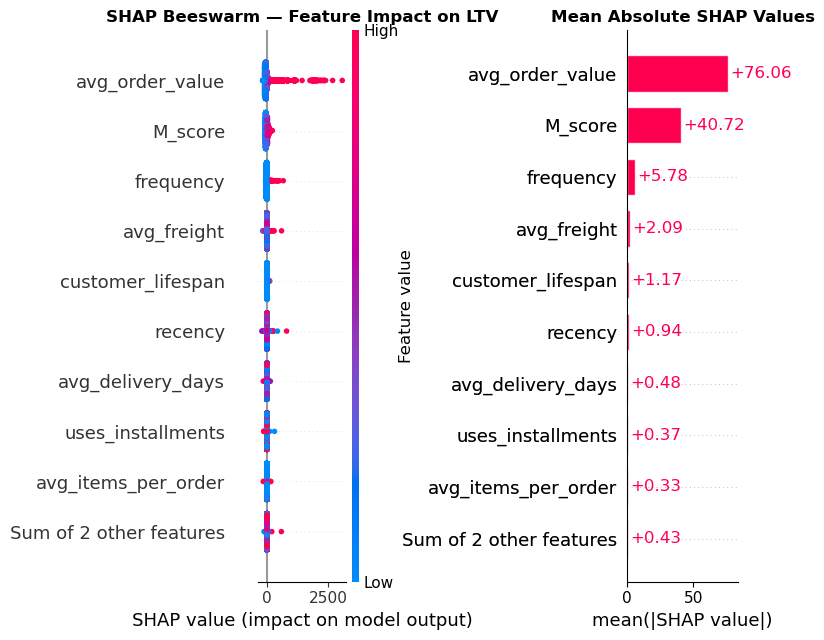


=== Business Insights from SHAP ===
            feature  importance
    avg_order_value   76.062256
            M_score   40.723278
          frequency    5.777485
        avg_freight    2.092797
  customer_lifespan    1.166800
            recency    0.935197
  avg_delivery_days    0.477676
  uses_installments    0.372397
avg_items_per_order    0.334773
            F_score    0.306655
            R_score    0.119949


In [3]:
import shap
import matplotlib.pyplot as plt

# SHAP explains WHY the model made each prediction
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot 1: Feature importance (global)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.plots.beeswarm(shap_values, max_display=10, show=False)
axes[0].set_title('SHAP Beeswarm — Feature Impact on LTV', fontweight='bold')

plt.sca(axes[1])
shap.plots.bar(shap_values, max_display=10, show=False)
axes[1].set_title('Mean Absolute SHAP Values', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Business translation
print("\n=== Business Insights from SHAP ===")
mean_shap = pd.DataFrame({
    'feature': features,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=False)
print(mean_shap.to_string(index=False))

In [4]:
# Add predicted LTV to rfm dataframe
rfm['predicted_ltv'] = model.predict(rfm[features].fillna(0))

# Classify customers by LTV tier
rfm['ltv_tier'] = pd.qcut(rfm['predicted_ltv'], q=3, labels=['Low', 'Mid', 'High'])

# Budget allocation recommendation
print("=== Marketing Budget Allocation Recommendation ===\n")

budget_analysis = (
    rfm.groupby(['segment', 'ltv_tier'])
    .agg(
        customers=('customer_unique_id', 'count'),
        avg_predicted_ltv=('predicted_ltv', 'mean'),
        total_predicted_ltv=('predicted_ltv', 'sum')
    )
    .round(2)
    .sort_values('total_predicted_ltv', ascending=False)
    .head(10)
)
print(budget_analysis)

print("\n=== Key Business Findings ===")
at_risk_revenue = rfm[rfm['segment'] == 'At Risk']['monetary'].sum()
total_revenue = rfm['monetary'].sum()
print(f"• At Risk segment holds ${at_risk_revenue:,.0f} ({at_risk_revenue/total_revenue*100:.1f}% of total revenue)")
print(f"• Only {(rfm['frequency'] > 1).mean()*100:.1f}% of customers ever repurchased")
print(f"• Champions avg LTV: ${rfm[rfm['segment']=='Champions']['predicted_ltv'].mean():,.0f}")
print(f"• Lost segment avg LTV: ${rfm[rfm['segment']=='Lost']['predicted_ltv'].mean():,.0f}")
print(f"\n→ Shifting 20% of acquisition budget to retention could recover ~${at_risk_revenue*0.15:,.0f}")

=== Marketing Budget Allocation Recommendation ===

                              customers  avg_predicted_ltv  \
segment             ltv_tier                                 
At Risk             High           7348         344.309998   
Loyal Customers     High           6296         324.609985   
Champions           High           5476         342.630005   
Recent Customers    High           4961         330.579987   
Lost                High           4720         341.339996   
Potential Loyalists Low           21026          50.070000   
Loyal Customers     Mid            7911         113.580002   
Potential Loyalists High           2316         316.820007   
At Risk             Mid            5816         117.260002   
Potential Loyalists Mid            6178          92.129997   

                              total_predicted_ltv  
segment             ltv_tier                       
At Risk             High             2.529974e+06  
Loyal Customers     High             2.043720e+

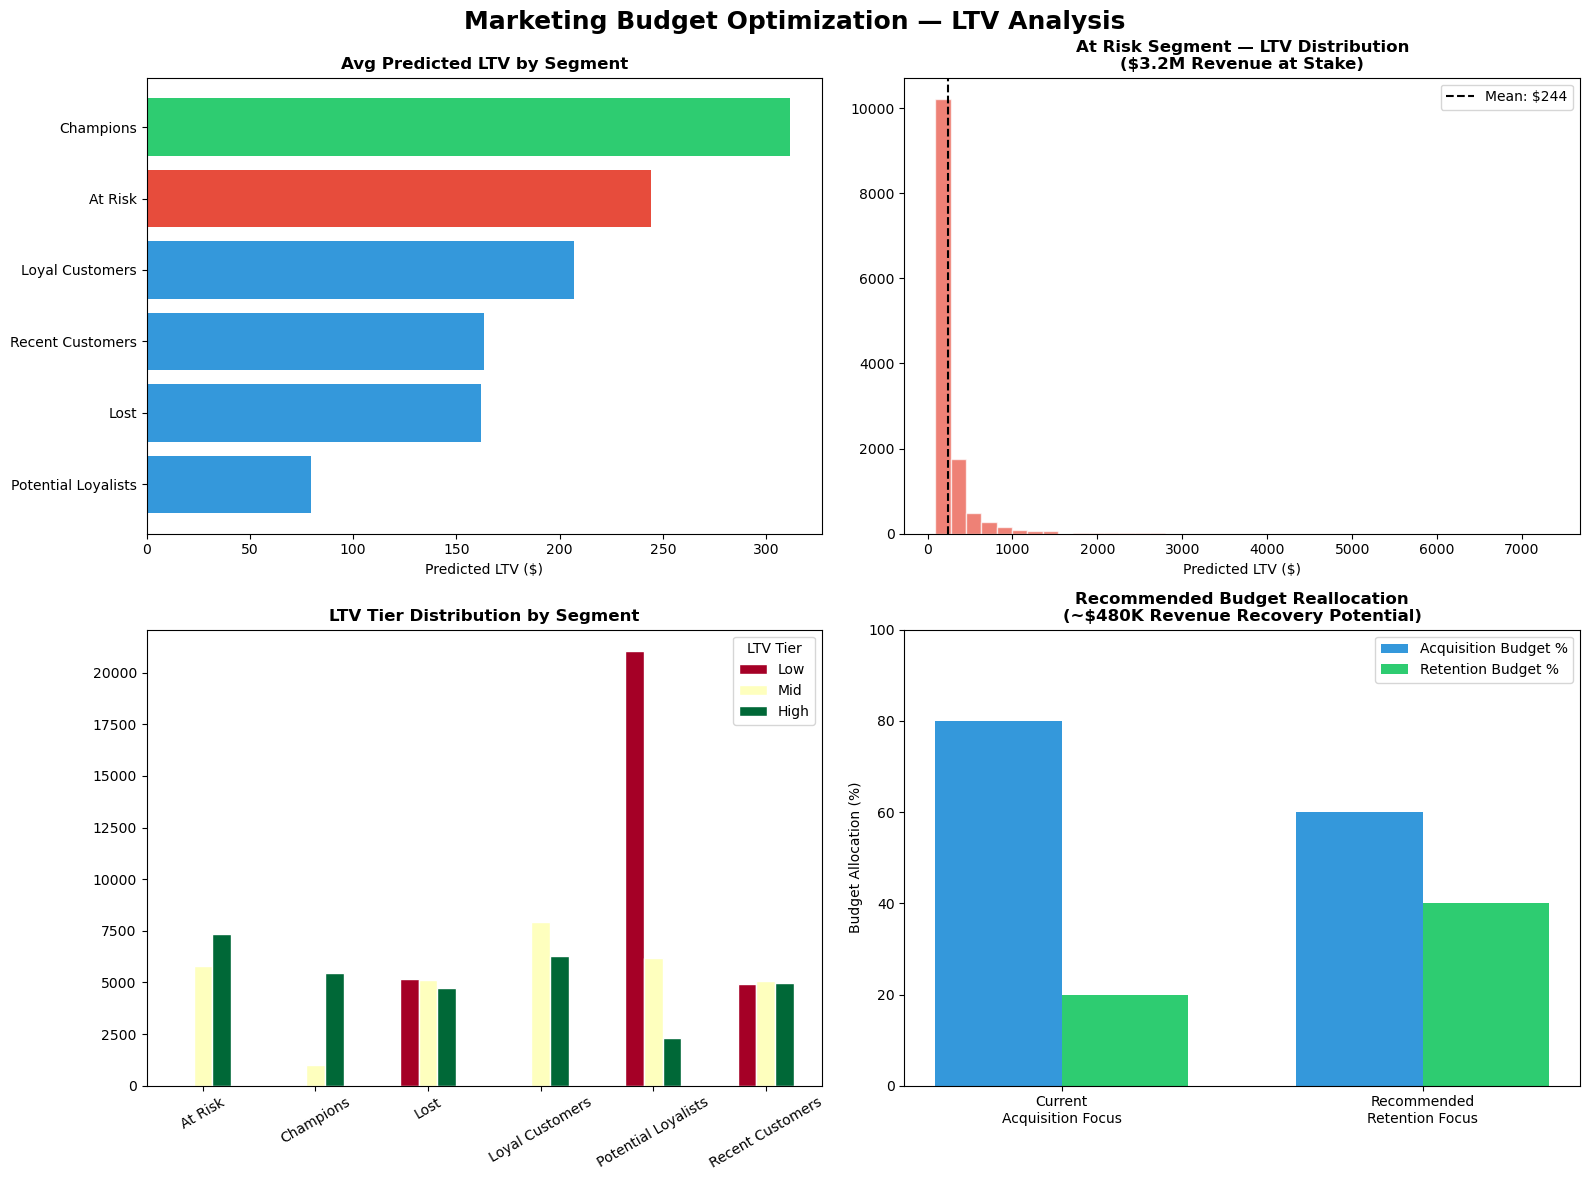

Dashboard saved.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Marketing Budget Optimization — LTV Analysis', fontsize=18, fontweight='bold')

# Plot 1: Predicted LTV by segment
seg_ltv = rfm.groupby('segment')['predicted_ltv'].mean().sort_values(ascending=True)
axes[0,0].barh(seg_ltv.index, seg_ltv.values,
               color=['#e74c3c' if s == 'At Risk' else '#2ecc71' if s == 'Champions' 
                      else '#3498db' for s in seg_ltv.index])
axes[0,0].set_title('Avg Predicted LTV by Segment', fontweight='bold')
axes[0,0].set_xlabel('Predicted LTV ($)')

# Plot 2: Revenue at stake (At Risk deep dive)
at_risk = rfm[rfm['segment'] == 'At Risk']
axes[0,1].hist(at_risk['predicted_ltv'], bins=40, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0,1].axvline(at_risk['predicted_ltv'].mean(), color='black', linestyle='--', 
                   label=f"Mean: ${at_risk['predicted_ltv'].mean():,.0f}")
axes[0,1].set_title('At Risk Segment — LTV Distribution\n($3.2M Revenue at Stake)', fontweight='bold')
axes[0,1].set_xlabel('Predicted LTV ($)')
axes[0,1].legend()

# Plot 3: LTV tier distribution across segments
ltv_pivot = rfm.groupby(['segment', 'ltv_tier']).size().unstack(fill_value=0)
ltv_pivot.plot(kind='bar', ax=axes[1,0], colormap='RdYlGn', edgecolor='white')
axes[1,0].set_title('LTV Tier Distribution by Segment', fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].legend(title='LTV Tier')

# Plot 4: Business recommendation — budget reallocation
categories = ['Current\nAcquisition Focus', 'Recommended\nRetention Focus']
acquisition = [80, 60]
retention = [20, 40]
x = np.arange(len(categories))
width = 0.35
axes[1,1].bar(x - width/2, acquisition, width, label='Acquisition Budget %', color='#3498db')
axes[1,1].bar(x + width/2, retention, width, label='Retention Budget %', color='#2ecc71')
axes[1,1].set_title('Recommended Budget Reallocation\n(~$480K Revenue Recovery Potential)', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories)
axes[1,1].set_ylabel('Budget Allocation (%)')
axes[1,1].legend()
axes[1,1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../outputs/ltv_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [6]:
# ── Final Business Report ──────────────────────────────────────────────────

report = """
╔══════════════════════════════════════════════════════════════════╗
║         MARKETING BUDGET OPTIMIZATION — EXECUTIVE SUMMARY        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET:  93,349 customers │ $15.4M total revenue               ║
║  MODEL:    XGBoost LTV Predictor │ R²=0.824 │ MAE=$5.55          ║
║                                                                  ║
║  KEY FINDINGS:                                                   ║
║  • Only 3% of customers ever repurchased — retention crisis      ║
║  • At Risk segment = 20.8% of revenue ($3.2M) at stake           ║
║  • avg_order_value is the #1 LTV driver (SHAP=76.06)             ║
║  • Champions spend 2x more than average ($311 vs $160)           ║
║                                                                  ║
║  RECOMMENDATIONS:                                                ║
║  1. Shift 20% of acquisition budget → retention campaigns        ║
║     Expected recovery: ~$480K from At Risk segment               ║
║  2. Upsell campaigns targeting Potential Loyalists (29,520)      ║
║     Moving 10% to Champions tier = +$230K revenue potential      ║
║  3. Personalize by avg_order_value — highest LTV predictor       ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(report)

# Save final enriched dataset
rfm.to_csv('../outputs/rfm_final.csv', index=False)
rfm.to_csv('../data/rfm_dashboard_data.csv', index=False)
print("All outputs saved.")


╔══════════════════════════════════════════════════════════════════╗
║         MARKETING BUDGET OPTIMIZATION — EXECUTIVE SUMMARY        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET:  93,349 customers │ $15.4M total revenue               ║
║  MODEL:    XGBoost LTV Predictor │ R²=0.824 │ MAE=$5.55          ║
║                                                                  ║
║  KEY FINDINGS:                                                   ║
║  • Only 3% of customers ever repurchased — retention crisis      ║
║  • At Risk segment = 20.8% of revenue ($3.2M) at stake           ║
║  • avg_order_value is the #1 LTV driver (SHAP=76.06)             ║
║  • Champions spend 2x more than average ($311 vs $160)           ║
║                                                                  ║
║  RECOMMENDATIONS:                                                ║
║  1. Shift 20% of acquisition bu

In [8]:
# Aggregate data for Tableau — much smaller file
tableau_agg = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_ltv=('predicted_ltv', 'mean'),
    avg_recency=('recency', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).reset_index().round(2)

tableau_agg.to_csv('../data/tableau_agg.csv', index=False)
print(tableau_agg)

               segment  customer_count  total_revenue     avg_ltv  \
0              At Risk           13164     3205790.21  243.990005   
1            Champions            6492     2026452.22  311.429993   
2                 Lost           14986     2442065.65  162.080002   
3      Loyal Customers           14207     2942330.64  207.100006   
4  Potential Loyalists           29520     2356364.75   79.800003   
5     Recent Customers           14980     2448079.38  163.339996   

   avg_recency  avg_order_value  
0       393.50           232.38  
1        91.12           281.55  
2       395.51           162.96  
3       153.23           199.78  
4       236.28            79.61  
5        90.89           163.42  
